In [1]:
# ============================================================
# GSM8K Best-of-N Candidate Pool Analysis
# Primary selectors: Math Shepherd PRM vs Skywork-RM
# Cross-check metrics: EM, verbosity drift, step drift,
#                      cross-RM generalization to Skywork/ArmoRM
# Outputs:
#   - gsm8k_migration_results.csv
#   - gsm8k_goodhart_curve.png
# ============================================================

# =========================
# Cell 1: Imports
# =========================
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [2]:
# =========================
# Cell 2: Paths / Config
# =========================
POOL_PATH = Path("/kaggle/input/datasets/pradeep01223/llama-gsm8k-pool/gsm8k_full_pool.jsonl")
ARMORM_PATH = Path("/kaggle/input/notebooks/rjjack0112/llama-gsm8k-armorm-score-p2/armorm_gsm8k_cache.csv")
SKYWORK_PATH = Path("/kaggle/input/notebooks/mrsstrange012/llama-gsm8k-skywork-score/skywork_gsm8k_scored.csv")
PRM_PATH = Path("/kaggle/input/notebooks/pradeep01223/llama-gsm8k-math-prm-score/mathshepherd_gsm8k_scored.csv")

OUT_CSV = Path("gsm8k_migration_results.csv")
OUT_PLOT = Path("gsm8k_goodhart_curve.png")

N_LIST = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512]

print("POOL_PATH exists:", POOL_PATH.exists())
print("ARMORM_PATH exists:", ARMORM_PATH.exists())
print("SKYWORK_PATH exists:", SKYWORK_PATH.exists())
print("PRM_PATH exists:", PRM_PATH.exists())

POOL_PATH exists: True
ARMORM_PATH exists: True
SKYWORK_PATH exists: True
PRM_PATH exists: True


In [3]:
# =========================
# Cell 3: Helper functions
# =========================
def normalize_answer(text: str) -> str:
    if pd.isna(text):
        return ""
    text = str(text).strip()
    return re.sub(r"\s+", " ", text)

def extract_final_numeric_answer(text: str):
    """
    Extract final numeric answer from GSM8K-style text.
    Handles formats like:
      '#### 42'
      'The answer is 42'
      '$42'
      '42.'
      '-3.5'
      '1,234'
    Returns normalized numeric string if found, else cleaned trailing text heuristic.
    """
    if pd.isna(text):
        return None

    s = str(text).strip()

    # Prefer GSM8K gold format marker ####
    m = re.search(r"####\s*([-+]?\$?\d[\d,]*(?:\.\d+)?)", s)
    if m:
        ans = m.group(1).replace("$", "").replace(",", "").strip()
        return ans

    # Search all numbers; use the last one as final answer heuristic
    nums = re.findall(r"[-+]?\$?\d[\d,]*(?:\.\d+)?", s)
    if nums:
        ans = nums[-1].replace("$", "").replace(",", "").strip()
        return ans

    # Fallback: last non-empty line/text chunk
    parts = [p.strip() for p in re.split(r"[\n\r]+", s) if p.strip()]
    if parts:
        return parts[-1]

    return normalize_answer(s)

def exact_match(pred, gold) -> int:
    p = extract_final_numeric_answer(pred)
    g = extract_final_numeric_answer(gold)
    if p is None or g is None:
        return 0
    return int(str(p).strip() == str(g).strip())

def word_count(text: str) -> int:
    if pd.isna(text):
        return 0
    return len(re.findall(r"\S+", str(text)))

def step_count(text: str) -> int:
    if pd.isna(text):
        return 0
    s = str(text)
    newline_steps = s.count("\n")
    keyword_steps = len(re.findall(r"\b[Ss]tep\b", s))
    numbered_steps = len(re.findall(r"(?m)^\s*(?:\d+[\).\:]|-)\s+", s))
    return max(newline_steps, keyword_steps, numbered_steps)

def safe_mean(series):
    if len(series) == 0:
        return np.nan
    return float(np.mean(series))

def min_available_n(group_size, requested_n):
    return min(group_size, requested_n)

In [4]:
# =========================
# Cell 4: Load pool JSONL
# =========================
pool_rows = []

with open(POOL_PATH, "r", encoding="utf-8") as f:
    for line in f:
        rec = json.loads(line)
        pid = rec["prompt_id"]
        instruction = rec["instruction"]
        gold_answer = rec["answer"]
        candidates = rec["candidates"]

        for cand_idx, cand_text in enumerate(candidates):
            pool_rows.append(
                {
                    "prompt_id": int(pid),
                    "cand_idx": int(cand_idx),
                    "instruction": instruction,
                    "gold_answer": gold_answer,
                    "candidate_text": cand_text,
                }
            )

pool_df = pd.DataFrame(pool_rows)
print("Pool rows:", len(pool_df))
print("Num prompts:", pool_df["prompt_id"].nunique())
print("Candidates per prompt (sample):")
print(pool_df.groupby("prompt_id").size().describe())

Pool rows: 256000
Num prompts: 500
Candidates per prompt (sample):
count    500.0
mean     512.0
std        0.0
min      512.0
25%      512.0
50%      512.0
75%      512.0
max      512.0
dtype: float64


In [5]:
# =========================
# Cell 5: Load score files
# =========================
arm_df = pd.read_csv(ARMORM_PATH)
sky_df = pd.read_csv(SKYWORK_PATH)
prm_df = pd.read_csv(PRM_PATH)

print("ArmoRM columns:", arm_df.columns.tolist())
print("Skywork columns:", sky_df.columns.tolist())
print("PRM columns:", prm_df.columns.tolist())

ArmoRM columns: ['promptid', 'candidx', 'armorm_raw']
Skywork columns: ['prompt_id', 'candidx', 'skywork_raw', 'answer', 'text']
PRM columns: ['prompt_id', 'cand_idx', 'mathshepherd_raw', 'instruction', 'answer', 'text']


In [6]:
# =========================
# Cell 6: Standardize score schemas
# =========================
arm_df = arm_df.rename(columns={
    "promptid": "prompt_id",
    "candidx": "cand_idx",
    "armorm_raw": "armorm_raw"
})[["prompt_id", "cand_idx", "armorm_raw"]].copy()

sky_keep_cols = [c for c in ["prompt_id", "candidx", "skywork_raw"] if c in sky_df.columns]
sky_df = sky_df[sky_keep_cols].rename(columns={
    "candidx": "cand_idx"
}).copy()

prm_keep_cols = [c for c in ["prompt_id", "cand_idx", "cand_idx", "mathshepherd_raw"] if c in prm_df.columns]
prm_df = prm_df.rename(columns={"cand_idx": "cand_idx"})  # no-op but explicit
if "cand_idx" not in prm_df.columns and "candidx" in prm_df.columns:
    prm_df = prm_df.rename(columns={"candidx": "cand_idx"})
prm_df = prm_df[["prompt_id", "cand_idx", "mathshepherd_raw"]].copy()

for df in [arm_df, sky_df, prm_df]:
    df["prompt_id"] = df["prompt_id"].astype(int)
    df["cand_idx"] = df["cand_idx"].astype(int)

print("ArmoRM rows:", len(arm_df))
print("Skywork rows:", len(sky_df))
print("PRM rows:", len(prm_df))

ArmoRM rows: 256000
Skywork rows: 256000
PRM rows: 256000


In [7]:
# =========================
# Cell 7: Merge everything
# =========================
df = (
    pool_df
    .merge(prm_df, on=["prompt_id", "cand_idx"], how="left")
    .merge(sky_df, on=["prompt_id", "cand_idx"], how="left")
    .merge(arm_df, on=["prompt_id", "cand_idx"], how="left")
)

# Optional text consistency check if score files contain text columns externally
df["word_count"] = df["candidate_text"].apply(word_count)
df["step_count"] = df["candidate_text"].apply(step_count)
df["em"] = [exact_match(p, g) for p, g in zip(df["candidate_text"], df["gold_answer"])]

print("Merged shape:", df.shape)
print(df.head(3))

missing_summary = df[["mathshepherd_raw", "skywork_raw", "armorm_raw"]].isna().mean().rename("missing_fraction")
print("\nMissing score fraction:")
print(missing_summary)

Merged shape: (256000, 11)
   prompt_id  cand_idx                                        instruction                                        gold_answer                                     candidate_text  mathshepherd_raw  \
0          0         0  Janet’s ducks lay 16 eggs per day. She eats th...  Janet sells 16 - 3 - 4 = <<16-3-4=9>>9 duck eg...  To find out how much Janet makes every day at ...       -580.222046   
1          0         1  Janet’s ducks lay 16 eggs per day. She eats th...  Janet sells 16 - 3 - 4 = <<16-3-4=9>>9 duck eg...  To find out how much Janet makes at the farmer...       -567.291138   
2          0         2  Janet’s ducks lay 16 eggs per day. She eats th...  Janet sells 16 - 3 - 4 = <<16-3-4=9>>9 duck eg...  To solve this problem, let's break it down int...       -641.638855   

   skywork_raw  armorm_raw  word_count  step_count  em  
0     8.130369    0.132324         139          18   1  
1    11.985624    0.140503         132          14   1  
2    13.45949

In [8]:

# =========================
# Cell 8: Basic validation
# =========================
prompt_sizes = df.groupby("prompt_id").size()
print("Candidate count per prompt:")
print(prompt_sizes.describe())

score_coverage = (
    df.groupby("prompt_id")[["mathshepherd_raw", "skywork_raw", "armorm_raw"]]
      .apply(lambda x: pd.Series({
          "prm_nonnull": x["mathshepherd_raw"].notna().sum(),
          "sky_nonnull": x["skywork_raw"].notna().sum(),
          "arm_nonnull": x["armorm_raw"].notna().sum(),
      }))
)
print("\nPer-prompt score coverage summary:")
print(score_coverage.describe())

Candidate count per prompt:
count    500.0
mean     512.0
std        0.0
min      512.0
25%      512.0
50%      512.0
75%      512.0
max      512.0
dtype: float64

Per-prompt score coverage summary:
       prm_nonnull  sky_nonnull  arm_nonnull
count        500.0        500.0        500.0
mean         512.0        512.0        512.0
std            0.0          0.0          0.0
min          512.0        512.0        512.0
25%          512.0        512.0        512.0
50%          512.0        512.0        512.0
75%          512.0        512.0        512.0
max          512.0        512.0        512.0


In [9]:
# =========================
# Cell 9: Selection evaluator
# =========================
def evaluate_selector(full_df: pd.DataFrame, selector_col: str, selector_name: str, n_list):
    rows = []

    for N in n_list:
        selected_rows = []

        for pid, g in full_df.groupby("prompt_id", sort=True):
            g = g.sort_values("cand_idx").copy()
            topn = g.iloc[:min_available_n(len(g), N)].copy()

            valid = topn[topn[selector_col].notna()].copy()
            if len(valid) == 0:
                continue

            valid = valid.sort_values(
                by=[selector_col, "cand_idx"],
                ascending=[False, True]
            )
            best = valid.iloc[0]
            selected_rows.append(best)

        sel = pd.DataFrame(selected_rows).reset_index(drop=True)

        row = {
            "selector": selector_name,
            "N": int(N),
            "num_prompts_used": int(sel["prompt_id"].nunique()),
            "selector_score_mean": safe_mean(sel[selector_col]),
            "em_accuracy": safe_mean(sel["em"]),
            "em_accuracy_pct": 100.0 * safe_mean(sel["em"]),
            "avg_word_count": safe_mean(sel["word_count"]),
            "avg_step_count": safe_mean(sel["step_count"]),
            "avg_skywork_raw": safe_mean(sel["skywork_raw"]),
            "avg_armorm_raw": safe_mean(sel["armorm_raw"]),
            "avg_mathshepherd_raw": safe_mean(sel["mathshepherd_raw"]),
        }
        rows.append(row)

    out = pd.DataFrame(rows).sort_values(["selector", "N"]).reset_index(drop=True)
    return out

math_results = evaluate_selector(df, "mathshepherd_raw", "MathShepherd", N_LIST)
sky_results = evaluate_selector(df, "skywork_raw", "SkyworkRM", N_LIST)

results = pd.concat([math_results, sky_results], ignore_index=True)
results

,selector,N,num_prompts_used,selector_score_mean,em_accuracy,em_accuracy_pct,avg_word_count,avg_step_count,avg_skywork_raw,avg_armorm_raw,avg_mathshepherd_raw
0,MathShepherd,1,500,-560.824499,0.658,65.8,150.838,16.658,3.142579,0.143253,-560.824499
1,MathShepherd,2,500,-483.287287,0.612,61.2,152.808,17.214,1.583134,0.141277,-483.287287
2,MathShepherd,4,500,-410.759893,0.558,55.8,155.378,17.062,0.163177,0.139201,-410.759893
3,MathShepherd,8,500,-333.939430,0.496,49.6,160.908,17.380,-1.542967,0.137915,-333.939430
4,MathShepherd,16,500,-248.100039,0.442,44.2,165.526,17.472,-3.084417,0.134889,-248.100039
5,MathShepherd,32,500,-159.257104,0.402,40.2,168.520,17.760,-4.154572,0.133745,-159.257104
6,MathShepherd,64,500,-78.006470,0.354,35.4,170.358,17.854,-4.973600,0.132456,-78.006470
7,MathShepherd,128,500,5.667116,0.324,32.4,173.176,18.394,-5.455984,0.131622,5.667116
8,MathShepherd,256,500,67.705230,0.306,30.6,175.640,18.462,-5.839895,0.131148,67.705230
9,MathShepherd,512,500,126.756132,0.282,28.2,179.700,18.556,-7.203770,0.128389,126.756132


In [10]:
# =========================
# Cell 10: Migration heuristics
# =========================
def assess_migration(res_df: pd.DataFrame, selector_name: str) -> dict:
    d = res_df[res_df["selector"] == selector_name].sort_values("N").reset_index(drop=True)

    if len(d) < 2:
        return {
            "selector": selector_name,
            "migration_observed": "Insufficient data",
            "reason": "Need at least two N points."
        }

    selector_gain = d["selector_score_mean"].iloc[-1] - d["selector_score_mean"].iloc[0]
    em_gain = d["em_accuracy_pct"].iloc[-1] - d["em_accuracy_pct"].iloc[0]
    wc_gain = d["avg_word_count"].iloc[-1] - d["avg_word_count"].iloc[0]
    step_gain = d["avg_step_count"].iloc[-1] - d["avg_step_count"].iloc[0]

    score_monotone = d["selector_score_mean"].is_monotonic_increasing
    em_peak_idx = d["em_accuracy_pct"].idxmax()
    em_declines_after_peak = em_peak_idx < len(d) - 1 and d["em_accuracy_pct"].iloc[-1] < d["em_accuracy_pct"].iloc[em_peak_idx]
    verbosity_up = (wc_gain > 0) or (step_gain > 0)

    # Conservative rule:
    # migration observed if selector score rises, and either
    # (a) EM declines after peaking, or
    # (b) EM gain is weak while verbosity rises substantially
    weak_em = em_gain <= 2.0
    strong_score_pressure = abs(selector_gain) > 1e-12

    migration = strong_score_pressure and (
        em_declines_after_peak or (weak_em and verbosity_up)
    )

    reason_parts = []
    reason_parts.append(f"selector_score Δ={selector_gain:.4f}")
    reason_parts.append(f"EM% Δ={em_gain:.2f}")
    reason_parts.append(f"word_count Δ={wc_gain:.2f}")
    reason_parts.append(f"step_count Δ={step_gain:.2f}")
    reason_parts.append(f"score_monotone={score_monotone}")
    reason_parts.append(f"em_declines_after_peak={em_declines_after_peak}")

    return {
        "selector": selector_name,
        "migration_observed": "Yes" if migration else "No",
        "reason": "; ".join(reason_parts)
    }

migration_math = assess_migration(results, "MathShepherd")
migration_sky = assess_migration(results, "SkyworkRM")

migration_df = pd.DataFrame([migration_math, migration_sky])
migration_df

,selector,migration_observed,reason
0,MathShepherd,Yes,selector_score Δ=687.5806; EM% Δ=-37.60; word_...
1,SkyworkRM,No,selector_score Δ=16.2484; EM% Δ=20.60; word_co...


In [11]:
# =========================
# Cell 11: Summary comparison table
# =========================
summary_cols = [
    "N",
    "selector_score_mean",
    "em_accuracy_pct",
    "avg_word_count",
    "avg_step_count",
    "avg_skywork_raw",
    "avg_armorm_raw",
]

math_show = math_results[summary_cols].copy()
math_show.columns = [
    "N",
    "MathShepherd_sel_score",
    "MathShepherd_EM_pct",
    "MathShepherd_avg_words",
    "MathShepherd_avg_steps",
    "MathShepherd_avg_Skywork",
    "MathShepherd_avg_ArmoRM",
]

sky_show = sky_results[summary_cols].copy()
sky_show.columns = [
    "N",
    "Skywork_sel_score",
    "Skywork_EM_pct",
    "Skywork_avg_words",
    "Skywork_avg_steps",
    "Skywork_avg_Skywork",
    "Skywork_avg_ArmoRM",
]

summary = math_show.merge(sky_show, on="N", how="outer").sort_values("N").reset_index(drop=True)

# Rounded printable version
summary_print = summary.copy()
for c in summary_print.columns:
    if c != "N":
        summary_print[c] = summary_print[c].astype(float).round(4)

print("\n# GSM8K Best-of-N Migration Summary\n")
print(summary_print.to_markdown(index=False))

print("\n# Migration Verdicts\n")
print(migration_df.to_markdown(index=False))


# GSM8K Best-of-N Migration Summary

|   N |   MathShepherd_sel_score |   MathShepherd_EM_pct |   MathShepherd_avg_words |   MathShepherd_avg_steps |   MathShepherd_avg_Skywork |   MathShepherd_avg_ArmoRM |   Skywork_sel_score |   Skywork_EM_pct |   Skywork_avg_words |   Skywork_avg_steps |   Skywork_avg_Skywork |   Skywork_avg_ArmoRM |
|----:|-------------------------:|----------------------:|-------------------------:|-------------------------:|---------------------------:|--------------------------:|--------------------:|-----------------:|--------------------:|--------------------:|----------------------:|---------------------:|
|   1 |                -560.824  |                  65.8 |                  150.838 |                   16.658 |                     3.1426 |                    0.1433 |              3.1426 |             65.8 |             150.838 |              16.658 |                3.1426 |               0.1433 |
|   2 |                -483.287  |                  61.2

In [12]:
# =========================
# Cell 12: Save CSV
# =========================
results_export = results.merge(migration_df, on="selector", how="left")
results_export.to_csv(OUT_CSV, index=False)
print(f"Saved metrics to: {OUT_CSV.resolve()}")

Saved metrics to: /kaggle/working/gsm8k_migration_results.csv


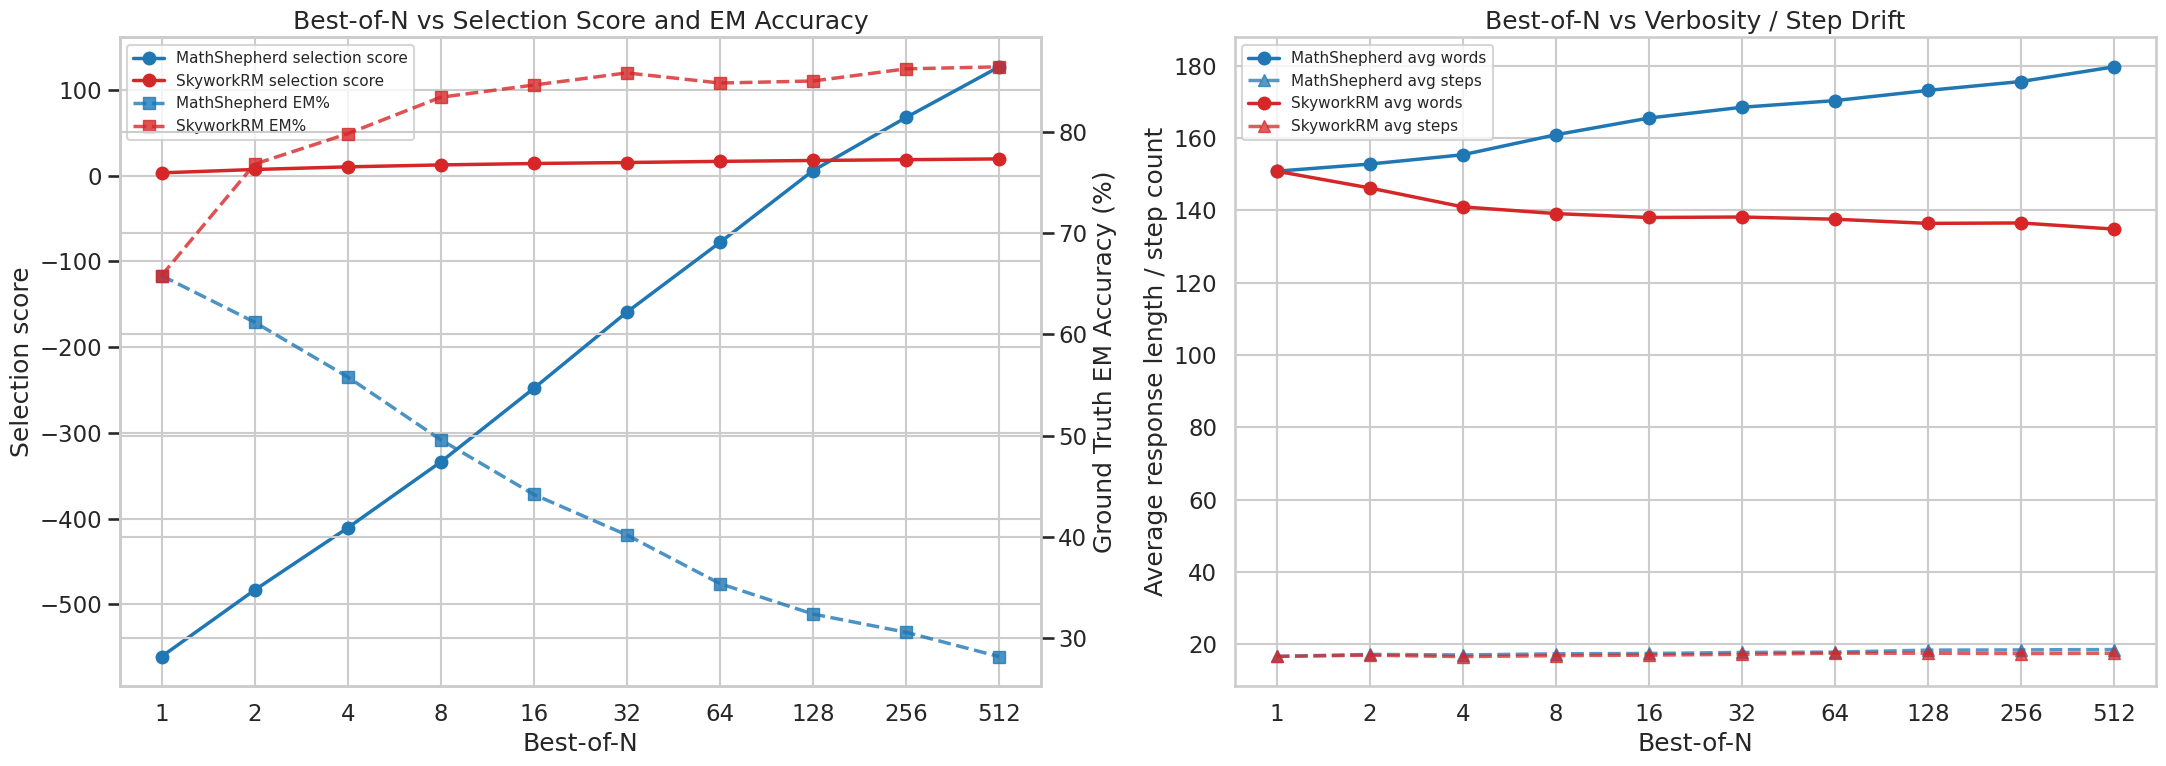

Saved plot to: /kaggle/working/gsm8k_goodhart_curve.png


In [13]:
# =========================
# Cell 13: Plot
# =========================
fig, axes = plt.subplots(1, 2, figsize=(22, 8))

palette = {
    "MathShepherd": "#1f77b4",
    "SkyworkRM": "#d62728",
}

# -------- Left panel --------
ax1 = axes[0]
ax1b = ax1.twinx()

for selector in ["MathShepherd", "SkyworkRM"]:
    d = results[results["selector"] == selector].sort_values("N")

    ax1.plot(
        d["N"], d["selector_score_mean"],
        marker="o", linewidth=2.5,
        color=palette[selector], label=f"{selector} selection score"
    )

    ax1b.plot(
        d["N"], d["em_accuracy_pct"],
        marker="s", linestyle="--", linewidth=2.5,
        color=palette[selector], alpha=0.8, label=f"{selector} EM%"
    )

ax1.set_xscale("log", base=2)
ax1.set_xticks(N_LIST)
ax1.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax1.set_xlabel("Best-of-N")
ax1.set_ylabel("Selection score")
ax1b.set_ylabel("Ground Truth EM Accuracy (%)")
ax1.set_title("Best-of-N vs Selection Score and EM Accuracy")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best", fontsize=11)

# -------- Right panel --------
ax2 = axes[1]

for selector in ["MathShepherd", "SkyworkRM"]:
    d = results[results["selector"] == selector].sort_values("N")

    ax2.plot(
        d["N"], d["avg_word_count"],
        marker="o", linewidth=2.5,
        color=palette[selector], label=f"{selector} avg words"
    )
    ax2.plot(
        d["N"], d["avg_step_count"],
        marker="^", linestyle="--", linewidth=2.5,
        color=palette[selector], alpha=0.75, label=f"{selector} avg steps"
    )

ax2.set_xscale("log", base=2)
ax2.set_xticks(N_LIST)
ax2.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax2.set_xlabel("Best-of-N")
ax2.set_ylabel("Average response length / step count")
ax2.set_title("Best-of-N vs Verbosity / Step Drift")
ax2.legend(loc="best", fontsize=11)

plt.tight_layout()
plt.savefig(OUT_PLOT, dpi=220, bbox_inches="tight")
plt.show()

print(f"Saved plot to: {OUT_PLOT.resolve()}")

In [14]:
# =========================
# Cell 14: Compact final verdict
# =========================
print("\n=== Migration verdict ===")
for _, row in migration_df.iterrows():
    print(f"{row['selector']}: Migration observed? {row['migration_observed']}")
    print(f"Reason: {row['reason']}")
    print("-" * 100)


=== Migration verdict ===
MathShepherd: Migration observed? Yes
Reason: selector_score Δ=687.5806; EM% Δ=-37.60; word_count Δ=28.86; step_count Δ=1.90; score_monotone=True; em_declines_after_peak=True
----------------------------------------------------------------------------------------------------
SkyworkRM: Migration observed? No
Reason: selector_score Δ=16.2484; EM% Δ=20.60; word_count Δ=-16.02; step_count Δ=0.86; score_monotone=True; em_declines_after_peak=False
----------------------------------------------------------------------------------------------------
